# Aspectos generales de programación y algoritmos

## Complejidad de algoritmos

### ¿Qué es un algoritmo?
Un algoritmo es una serie ordenada de operaciones sistemáticas que permite hacer un cálculo y hallar la solución de un tipo de problemas.

Por ejemplo:

In [1]:
def f(n):
    out = 0
    for i in range(n):
        for j in range(n):
            out += i*j
    return out

In [2]:
f(5)

100

La complejidad de un algoritmo es la **relación entre el tamaño del input $N$** y la **cantidad de operaciones para completarlo**.
Una forma de determinar la complejidad del algoritmo es **contabilizar las operaciones básicas**:
- sumas
- restas
- multiplicaciones
- divisiones
- asignación de variables
- llamados a otras funciones

Por ejemplo, en el siguiente algoritmo:

In [3]:
def f(n):
    out = 0
    for i in range(n):
        for j in range(n):
            out += i*j
    return out

El número de operaciones son:
- sumas: $N^2$
- restas: 0
- multiplicaciones: $N^2$
- divisiones: 0
- asignación de variables: $2N^2 + N + 1$
- llamados a otras funciones: 0

Así, el **total de operaciones** para completar el algoritmo es $4N^2+N+1$.

### Notación *Big-O*
A medida que el tamaño de $N$ aumenta, las operaciones de mayor orden se hacen dominantes. Así, podemos decir que la complejidad del algoritmo anterior es del orden $O(N^2)$. Esta notación, denominada ***Big-O***, es comúnmente utiilzada para **determinar la complejidad del algoritmo cuando $N$ es de gran tamaño**.

> **Nota** Un algoritmo tiene complejidad **polinomial** cuando es del tipo $O(N^c)$, donde $c$ es una constante.

### ¿Cómo deducimos el orden de un algoritmo?

En el ejemplo anterior pudimos **contar directamente** las operaciones, porque sabíamos de antemano cuántas veces se ejecutaba cada bucle ($N$ veces cada uno).

Esto **no siempre es posible**. Hay dos situaciones en que el conteo directo falla:

- el bucle **no avanza de a uno**, sino que *divide* el tamaño del problema (`n = n/2`),
- la función **se llama a sí misma** (recursión), y el número de llamados no es evidente.

Para estos casos usamos el siguiente procedimiento.

#### Método de los 4 pasos

| Paso | Pregunta que debemos responder | Qué obtenemos |
|:---:|:---|:---|
| **1** | ¿Cuál es el tamaño del input $N$? ¿Cuál es la **operación dominante**? | *qué* vamos a contar |
| **2** | ¿Cómo cambia el problema **de un paso al siguiente**? | la **ley de avance** |
| **3** | ¿Cuántos pasos $I$ se necesitan para terminar? | $I(N)$, despejado del paso 2 |
| **4** | ¿Cuál es el término dominante cuando $N \rightarrow \infty$? | $O(\cdot)$ |

> **Nota.** Los pasos 1 y 4 son siempre iguales. **El paso 2 es el que decide la familia de complejidad.**

#### El paso 2 define la familia

La pregunta clave es: **¿qué le ocurre al problema en cada paso?**

| Ley de avance en cada paso | N° de pasos $I(N)$ | Familia |
|:---|:---:|:---|
| al índice se le **suma** una constante: $i \leftarrow i+1$ | $N$ | lineal, $O(N)$ |
| $c$ bucles **anidados**, cada uno de ley aditiva | $N^c$ | polinomial, $O(N^c)$ |
| al tamaño se le **divide** por una constante: $n \leftarrow n/b$ | $\log_b N$ | logarítmica, $O(\log N)$ |
| el **número de tareas se multiplica** por $c$: $1 \rightarrow c \rightarrow c^2 \rightarrow \dots$ | $c^N$ | exponencial, $O(c^N)$ |

> **Regla mnemotécnica**
> - el avance **suma** $\;\rightarrow\;$ polinomial
> - el avance **divide** el tamaño $\;\rightarrow\;$ logarítmico
> - el avance **multiplica** la cantidad de tareas $\;\rightarrow\;$ exponencial

### Complejidad logarítmica

Apliquemos el método de los 4 pasos al siguiente algoritmo:

In [4]:
def my_divide_by_two(n):
    
    out = 0
    while n > 1:
        n /= 2
        out += 1
        
    return out

In [5]:
my_divide_by_two(10)

4

**Paso 1: tamaño del input y operación dominante.**

El input es el número $N$ (el valor de `n`). La parte dominante está dentro del bucle `while`: cada iteración ejecuta un número **fijo** de operaciones (una división, una suma y dos asignaciones), independiente de $N$. Entonces

\begin{equation}
\mathrm{Total~de~operaciones} = a \times I
\end{equation}

donde $a$ es el costo (constante) de **una** iteración e $I$ es el **número de iteraciones**. Como $a$ es constante, todo el problema se reduce a **contar iteraciones**.

**Paso 2: ley de avance.** ¿Qué le ocurre a `n` en cada iteración? Se **divide por 2**:

| Iteración $k$ | 0 | 1 | 2 | 3 | $\cdots$ | $k$ |
|:---|:---:|:---:|:---:|:---:|:---:|:---:|
| valor de `n` | $N$ | $\dfrac{N}{2}$ | $\dfrac{N}{4}$ | $\dfrac{N}{8}$ | $\cdots$ | $\dfrac{N}{2^k}$ |

La ley de avance es entonces

\begin{equation}
n_k = \frac{N}{2^k}
\end{equation}

**Paso 3: número de iteraciones.** El bucle se detiene cuando `n` deja de ser mayor que 1, es decir, en la iteración $I$ tal que $n_I \approx 1$:

\begin{equation}
\frac{N}{2^{I}} = 1
\quad \Longrightarrow \quad
2^{I} = N
\quad \Longrightarrow \quad
I = \log_2 N
\end{equation}

> El logaritmo aparece porque es, **por definición**, la operación inversa de multiplicar repetidamente. La pregunta *"¿cuántas veces debo dividir $N$ por 2 para llegar a 1?"* **es** la definición de $\log_2 N$.

**Paso 4: término dominante.** Si cada iteración cuesta $a$ operaciones, y fuera del bucle hay $b$ operaciones fijas:

\begin{equation}
\mathrm{Total} = a \log_2 N + b
\quad \Longrightarrow \quad
O(\log N)
\end{equation}

> **¿Por qué se escribe $O(\log N)$ sin indicar la base?**

Porque cambiar de base solo multiplica por una **constante**:

\begin{equation}
\log_b N = \frac{\log_2 N}{\log_2 b}
\end{equation}

y las constantes no afectan el orden. Dividir por 2, por 3 o por 10 en cada paso da exactamente lo mismo: todos son $O(\log N)$.

**Verificación numérica.** Contemos las iteraciones para distintos valores de $N$:

In [6]:
import numpy as np

def contar_iteraciones(N, b=2):
    """Cuenta cuántas veces se divide N por b hasta llegar a 1"""
    n, iteraciones = N, 0
    while n > 1:
        n = n / b
        iteraciones += 1
    return iteraciones

print(f"{'N':>10} {'iteraciones I':>14} {'log2(N)':>10}")
for N in [2, 4, 8, 16, 32, 1024, 10**6]:
    print(f'{N:>10} {contar_iteraciones(N):>14} {np.log2(N):>10.2f}')

         N  iteraciones I    log2(N)
         2              1       1.00
         4              2       2.00
         8              3       3.00
        16              4       4.00
        32              5       5.00
      1024             10      10.00
   1000000             20      19.93


#### La firma del orden logarítmico

En la tabla anterior, **cada vez que $N$ se duplica se agrega una sola iteración**:

\begin{equation}
I(2N) = \log_2 (2N) = \log_2 N + 1 = I(N) + 1
\end{equation}

Por eso un algoritmo $O(\log N)$ es extraordinariamente eficiente: pasar de $N = 10^3$ a $N = 10^6$ (mil veces más datos) **solo duplica** el trabajo.

#### Test de la firma: un diagnóstico rápido

Si podemos contar (o medir) el trabajo $T$ para $N$ y para $2N$, el orden queda determinado:

| Al duplicar $N$, el trabajo... | Orden |
|:---|:---|
| aumenta en una cantidad **constante**: $T + a$ | $O(\log N)$ |
| se **duplica**: $2T$ | $O(N)$ |
| se **cuadruplica**: $4T$ | $O(N^2)$ |
| se multiplica por $2^c$ | $O(N^c)$ |
| se **eleva al cuadrado**: $T^2$ | $O(2^N)$ |

> **Nota.** Para el caso exponencial es más cómodo el test complementario: al pasar de $N$ a $N+1$ el trabajo se **multiplica** por una constante.

#### Segundo ejemplo: búsqueda binaria

Buscar un valor dentro de una lista **ordenada** de $N$ elementos, descartando la mitad de los candidatos en cada paso.

In [7]:
def busqueda_binaria(lista, objetivo):
    """Busca 'objetivo' en una lista ordenada. Retorna (posición, n° de pasos)"""
    izq, der, pasos = 0, len(lista) - 1, 0

    while izq <= der:
        pasos += 1
        medio = (izq + der) // 2
        if lista[medio] == objetivo:
            return medio, pasos
        elif lista[medio] < objetivo:
            izq = medio + 1        # descartamos la mitad izquierda
        else:
            der = medio - 1        # descartamos la mitad derecha

    return None, pasos

**Paso 2.** El número de candidatos es $N,\; N/2,\; N/4,\; \dots,\; N/2^k$

**Paso 3.** El algoritmo termina cuando queda 1 candidato:

\begin{equation}
\frac{N}{2^{I}} = 1 \quad \Longrightarrow \quad I = \log_2 N
\end{equation}

**Paso 4.** $O(\log N)$

In [8]:
print(f"{'N':>10} {'pasos':>8} {'log2(N)':>10}")
for N in [10**3, 10**4, 10**5, 10**6, 10**7]:
    lista = range(N)                       # lista ordenada: 0, 1, 2, ..., N-1
    _, pasos = busqueda_binaria(lista, N - 1)
    print(f'{N:>10} {pasos:>8} {np.log2(N):>10.2f}')

         N    pasos    log2(N)
      1000       10       9.97
     10000       14      13.29
    100000       17      16.61
   1000000       20      19.93
  10000000       24      23.25


Notar que **buscar en 10 millones de datos toma solo 24 pasos**. Un algoritmo lineal ($O(N)$) requeriría, en promedio, 5 millones de comparaciones.

> **Nota** Un algoritmo tiene complejidad **logarítmica** cuando es del tipo $O(\log N)$.

### Serie de Fibonacci y complejidad exponencial

Una operación matemática puede ser ejecutada mediante algoritmos con diferente complejidad. Por ejemplo, consideremos la serie de Fibonacci.

<img src="./imagenes/Fibonacci.png" width="800" align= center>

Esta operación puede ejecutarse de dos maneras: (1) de forma iterativa, (2) de forma recursiva

**(1) Forma iterativa.** complejidad $O(N)$

In [9]:
def my_fib_iter(n):
    
    out = [1, 1]
    
    for i in range(2, n+1):
        out.append(out[i - 1] + out[i - 2])
        
    return out[-1]

In [10]:
my_fib_iter(6)

13

**(2) Forma recursiva.** complejidad $O\left(2^N\right)$

In [11]:
def my_fib_rec(n):
    
    if n < 2:
        out = 1
    else:
        out = my_fib_rec(n-1) + my_fib_rec(n-2)
        
    return out

In [12]:
my_fib_rec(5)

8

#### ¿Por qué la versión recursiva es exponencial?

En un algoritmo recursivo **no hay bucles que contar**: cada llamado genera nuevos llamados. El paso 2 del método (la ley de avance) se escribe ahora como una **relación de recurrencia**, respondiendo dos preguntas:

1. ¿**Cuántos llamados** genera cada ejecución de la función? $\;\rightarrow\;$ **ramificación** del árbol, $c$
2. ¿**Cuánto disminuye el tamaño** en cada llamado? $\;\rightarrow\;$ **profundidad** del árbol, $p$

Para `my_fib_rec`, cada llamado con $n \geq 2$ genera **dos** llamados, de tamaños $n-1$ y $n-2$. Si $T(n)$ es el número total de llamados:

\begin{equation}
T(n) = \underbrace{T(n-1) + T(n-2)}_{\mathrm{los~dos~llamados~hijos}} + \underbrace{1}_{\mathrm{el~llamado~actual}}
\end{equation}

con $T(0) = T(1) = 1$.

#### El árbol de recursión

Dibujar el árbol de llamados es **la herramienta central** para deducir la complejidad de un algoritmo recursivo. Para `my_fib_rec(5)`:

```
fib(5)
├── fib(4)
│   ├── fib(3)
│   │   ├── fib(2)
│   │   │   ├── fib(1)  ← hoja
│   │   │   └── fib(0)  ← hoja
│   │   └── fib(1)      ← hoja
│   └── fib(2)
│       ├── fib(1)      ← hoja
│       └── fib(0)      ← hoja
└── fib(3)
    ├── fib(2)
    │   ├── fib(1)      ← hoja
    │   └── fib(0)      ← hoja
    └── fib(1)          ← hoja
```

Del árbol observamos:

- Tiene **15 nodos**: se necesitan **15 llamados** a la función para calcular `my_fib_rec(5)`.
- Tiene **8 hojas**, y cada hoja devuelve un 1. Como el resultado es la suma de las hojas, `my_fib_rec(5)` $= 8$. **El valor calculado es igual al número de hojas**: por eso el costo del algoritmo crece tan rápido como la propia serie de Fibonacci.
- `fib(3)` se calcula **2 veces**, `fib(2)` **3 veces** y `fib(1)` **5 veces**. El algoritmo **recalcula** una y otra vez los mismos valores: ahí está el desperdicio que la versión iterativa evita.

#### Del árbol al orden: contar nodos

Un árbol en que **cada nodo genera $c$ hijos** y que tiene **profundidad $p$** contiene

\begin{equation}
1 + c + c^2 + \cdots + c^{p} \approx c^{p} \quad \mathrm{nodos}
\end{equation}

```
nivel 0 :                •                 1  = 2⁰ nodo
nivel 1 :        •               •         2  = 2¹ nodos
nivel 2 :    •       •       •       •     4  = 2² nodos
nivel 3 :  •   •   •   •   •   •   •   •   8  = 2³ nodos
   ⋮                     ⋮                 ⋮
nivel N :  • • • • • • • • • • • • • • •   2^N nodos
```

\begin{equation}
\mathrm{N^\circ~de~operaciones} \;\approx\; a \cdot c^{\,p}
\end{equation}

donde $a$ = trabajo por nodo, $c$ = **ramificación** y $p$ = **profundidad**.

Para `my_fib_rec`:

- la **ramificación** es $c = 2$ (cada llamado genera 2 llamados),
- el tamaño baja **restando** ($n \rightarrow n-1$), así que la **profundidad** es $p = N$.

\begin{equation}
T(N) \leq 2^{N}
\quad \Longrightarrow \quad
O(2^N)
\end{equation}

#### Tabla maestra: ramificación y profundidad

| Recurrencia | Ramificación $c$ | Profundidad $p$ | Trabajo total | Orden |
|:---|:---:|:---:|:---:|:---|
| $T(n) = T(n-1) + 1$ | 1 | $N$ | $N$ | $O(N)$ |
| $T(n) = T(n/2) + 1$ | 1 | $\log_2 N$ | $\log_2 N$ | $O(\log N)$ |
| $T(n) = 2\,T(n/2) + n$ | 2 | $\log_2 N$ | $N$ por nivel $\times \log_2 N$ niveles | $O(N \log N)$ |
| $T(n) = 2\,T(n-1) + 1$ | 2 | $N$ | $2^N$ | $O(2^N)$ |
| $T(n) = c\,T(n-1) + 1$ | $c$ | $N$ | $c^N$ | $O(c^N)$ |

> **La observación clave.** Lo que separa lo polinomial de lo exponencial **no es la recursión**, ni el número de llamados, sino **cómo disminuye el tamaño del problema**.

Con la misma ramificación $c = 2$:

\begin{equation}
\underbrace{2^{\log_2 N} = N}_{\mathrm{el~tamaño~se~divide}}
\qquad \mathrm{versus} \qquad
\underbrace{2^{N}}_{\mathrm{el~tamaño~se~resta}}
\end{equation}

Dividir el tamaño mantiene el algoritmo en el mundo **polinomial**; restarle una constante lo lleva al mundo **exponencial**.

**Verificación numérica.** Instrumentemos la función recursiva con un contador de llamados:

In [13]:
def my_fib_rec_contado(n, contador):

    contador[0] += 1               # registramos este llamado

    if n < 2:
        out = 1
    else:
        out = my_fib_rec_contado(n-1, contador) + my_fib_rec_contado(n-2, contador)

    return out

In [14]:
T = {}
for N in range(26):
    contador = [0]
    my_fib_rec_contado(N, contador)
    T[N] = contador[0]                     # n° de llamados para calcular fib(N)

print(f"{'N':>4} {'llamados T(N)':>15} {'T(N)/T(N-1)':>13}")
for N in [5, 10, 15, 20, 25]:
    print(f'{N:>4} {T[N]:>15,} {T[N]/T[N-1]:>13.3f}')

   N   llamados T(N)   T(N)/T(N-1)
   5              15         1.667
  10             177         1.624
  15           1,973         1.619
  20          21,891         1.618
  25         242,785         1.618


El cociente $T(N)/T(N-1)$ converge a un valor **constante**, $\varphi = \dfrac{1+\sqrt{5}}{2} \approx 1.618$ (la razón áurea):

\begin{equation}
T(N) \approx \varphi \cdot T(N-1)
\quad \Longrightarrow \quad
T(N) \sim \varphi^{\,N}
\end{equation}

*Cada vez que $N$ aumenta en 1, el trabajo se multiplica por una constante*: esa es exactamente la firma de un algoritmo exponencial.

> **Nota.** El conteo exacto entrega $T(N) = 2F(N+1) - 1 \sim \varphi^N$, con $\varphi \approx 1.618$. La cota $O(2^N)$ obtenida del árbol binario completo es **correcta pero conservadora**: supone que *ambas* ramas bajan solo en 1, cuando en realidad una de ellas baja en 2.
>
> Ambas expresiones describen un crecimiento **exponencial**, que es lo que importa para clasificar el algoritmo. Para `my_fib_rec(100)` la diferencia es entre $\approx$ 8 billones de años y $\approx$ 7 mil años: en ambos casos, inviable.

#### Otros algoritmos exponenciales típicos

| Problema | Conteo | Orden |
|:---|:---|:---|
| Torres de Hanoi con $N$ discos | $T(n) = 2T(n-1)+1$ | $O(2^N)$ |
| Generar todos los subconjuntos de $N$ elementos | cada elemento *está* o *no está*: $2 \times 2 \times \cdots \times 2$ | $O(2^N)$ |
| Probar todas las claves de $N$ dígitos | $10 \times 10 \times \cdots \times 10$ | $O(10^N)$ |
| Evaluar todas las rutas entre $N$ ciudades | $N!$ | peor que exponencial |

> **Regla práctica.** Si el algoritmo consiste en **explorar todas las combinaciones posibles**, es exponencial.

> **Nota.** Un algoritmo tiene complejidad **exponencial** cuando es del tipo $O(c^N)$, donde $c$ es una constante.

### Cómo identificar el orden a partir de mediciones

Cuando el algoritmo es demasiado complejo para analizarlo en el papel, podemos **contar** (o medir) las operaciones y graficar. El truco es elegir la escala que **convierte la curva en una recta**:

| Si el orden es... | el gráfico que lo linealiza es... | y la recta tiene... |
|:---|:---|:---|
| $O(\log N)$ | semilog en $x$ | $T$ vs. $\log N$ lineal |
| $O(N^c)$ | log-log | **pendiente $= c$** |
| $O(c^N)$ | semilog en $y$ | **pendiente $= \ln c$** |

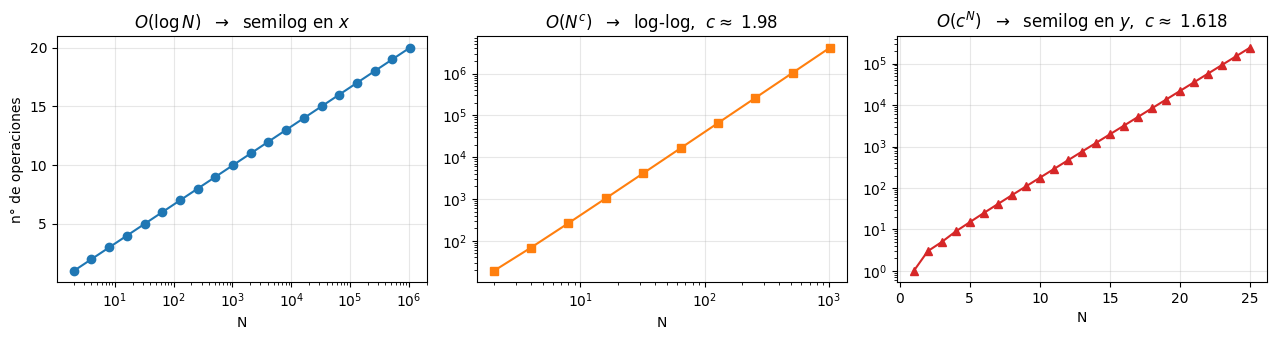

In [15]:
import matplotlib.pyplot as plt

# --- número de operaciones de cada algoritmo ---
def ops_log(N):                            # my_divide_by_two
    n, k = N, 0
    while n > 1:
        n /= 2
        k += 1
    return k

def ops_poly(N):                           # f(n): dos bucles anidados
    return 4*N**2 + N + 1

def ops_exp(N):                            # my_fib_rec
    contador = [0]
    my_fib_rec_contado(N, contador)
    return contador[0]

N_log  = np.array([2**k for k in range(1, 21)])
N_poly = np.array([2**k for k in range(1, 11)])
N_exp  = np.arange(1, 26)

T_log  = np.array([ops_log(N)  for N in N_log])
T_poly = np.array([ops_poly(N) for N in N_poly])
T_exp  = np.array([ops_exp(N)  for N in N_exp])

fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))

ax[0].semilogx(N_log, T_log, 'o-')
ax[0].set_title(r'$O(\log N)$  $\rightarrow$  semilog en $x$')

ax[1].loglog(N_poly, T_poly, 's-', color='tab:orange')
c = np.polyfit(np.log(N_poly), np.log(T_poly), 1)[0]
ax[1].set_title(r'$O(N^c)$  $\rightarrow$  log-log,  $c \approx$ %.2f' % c)

ax[2].semilogy(N_exp, T_exp, '^-', color='tab:red')
c = np.exp(np.polyfit(N_exp[10:], np.log(T_exp[10:]), 1)[0])
ax[2].set_title(r'$O(c^N)$  $\rightarrow$  semilog en $y$,  $c \approx$ %.3f' % c)

for a in ax:
    a.set_xlabel('N')
    a.grid(alpha=0.3)
ax[0].set_ylabel('n° de operaciones')

plt.tight_layout()
plt.show()

- **Izquierda:** los puntos caen en una recta *solo* al usar eje $x$ logarítmico $\rightarrow \; O(\log N)$.
- **Centro:** recta en log-log con pendiente $\approx 2 \rightarrow \; O(N^2)$, consistente con $4N^2+N+1$.
- **Derecha:** recta en semilog-$y \rightarrow$ exponencial, con base $c \approx 1.618 = \varphi$.

> **Nota.** Este procedimiento es el mismo que usaremos más adelante en el curso para determinar el **orden de convergencia** de un método numérico.

### Notación *Big-O* y tiempo de computación
La complejidad en la notación *Big-O* nos entrega una referencia del tiempo computacional dedicado para un determinado algoritmo.

<img src="./imagenes/08.02.01-complexity.png" width="300" align= center>

Así, por ejemplo, si consideramos un procesador Intel i7-12700K - 5GHz *($\approx$ 5 mil millones de operaciones por segundo)*:
- ```my_fib_iter(100)``` <br>tomaría $\approx$ 0.2 nanosegundos
<br>
- ```my_fib_recur(100)``` <br>tomaría $\approx$ 8 billones de años

Podemos evaluar el tiempo de ejecución con la sentencia ```%time```

In [16]:
%time a = my_fib_iter(30)

CPU times: user 5 µs, sys: 4 µs, total: 9 µs
Wall time: 10.7 µs


In [17]:
%time a = my_fib_rec(30) # No probar N>30

CPU times: user 110 ms, sys: 350 µs, total: 111 ms
Wall time: 110 ms


> **nota** En general, se deben evitar los algoritmos de complejidad exponencial

### Resumen: diagnóstico en 3 preguntas

**1. ¿El algoritmo es recursivo?**
   - **No** $\rightarrow$ analizar los bucles (pregunta 2)
   - **Sí** $\rightarrow$ dibujar el árbol de recursión (pregunta 3)

**2. Bucles: ¿cómo avanza el índice?**
   - **Suma** una constante ($i \leftarrow i+1$) $\rightarrow$ $N$ iteraciones. Los bucles anidados **multiplican**: $O(N^c)$
   - **Divide** el tamaño ($n \leftarrow n/b$) $\rightarrow$ $\log_b N$ iteraciones: $O(\log N)$

**3. Recursión: ¿cuál es la ramificación $c$ y la profundidad $p$?**
   - $\mathrm{N^\circ~de~operaciones} \approx (\mathrm{trabajo~por~nodo}) \times c^{\,p}$
   - el tamaño baja **restando** $\rightarrow p = N \rightarrow$ **exponencial**
   - el tamaño baja **dividiendo** $\rightarrow p = \log_2 N \rightarrow$ **polinomial**

**Y siempre:** verificar con el test de la firma (duplicar $N$) o con el gráfico que linealiza.

> **Errores frecuentes**
>
> - *"Si hay recursión, es exponencial"*. **Falso**: la búsqueda binaria recursiva es $O(\log N)$. Importa la ramificación **junto con** la profundidad.
> - *"Si hay dos llamados recursivos, es $O(2^N)$"*. **Falso** cuando el tamaño se divide: $2^{\log_2 N} = N$.
> - Confundir $O(\log N)$ con $O(N \log N)$: el primero **no recorre** todos los datos; el segundo sí.
> - Preocuparse de la base del logaritmo o de las constantes: no cambian el orden.

### Ejercicios propuestos

Determinar el orden de complejidad de los siguientes algoritmos, aplicando el método de los 4 pasos.

In [18]:
def alg_1(n):
    out, i = 0, 1
    while i < n:
        out += i
        i = i * 3
    return out

def alg_2(n):
    out = 0
    for i in range(n):
        j = n
        while j > 1:
            j = j / 2
            out += 1
    return out

def alg_3(n):
    if n <= 1:
        return 1
    return alg_3(n - 1) + alg_3(n - 1)

def alg_4(n):
    if n <= 1:
        return 1
    return alg_4(n // 2) + 1

> **Respuestas**
>
> - `alg_1`: el índice avanza **multiplicando** por 3, luego $3^I = N \Rightarrow I = \log_3 N$. $\;\rightarrow\; O(\log N)$
> - `alg_2`: bucle externo $N$ veces, bucle interno $\log_2 N$ veces (anidados $\rightarrow$ se multiplican). $\;\rightarrow\; O(N \log N)$
> - `alg_3`: ramificación $c = 2$, el tamaño baja **restando** $\rightarrow p = N$. $\;\rightarrow\; O(2^N)$
> - `alg_4`: ramificación $c = 1$, el tamaño baja **dividiendo** $\rightarrow p = \log_2 N$. $\;\rightarrow\; O(\log N)$
>
> Verificar cada respuesta instrumentando las funciones con un contador, como se hizo en los ejemplos.

## Error absoluto y relativo

Como veremos a lo largo del curso, los métodos numéricos se basan en *aproximaciones* para representar funciones y operaciones complejas. Estas aproximaciones pueden producir dos tipos de errores:
- Errores de truncamiento: debido al uso expresiones aproximadas del procedimiento matemático exacto
- Errores de redondeo: debido a las limitaciones de representación numérica propias del computador

Para cuantificar el error utilizamos dos tipos de métricas

**Error absoluto** Corresponde al error neto de la propuesta numérica:

\begin{equation}
E_\mathrm{abs} = |\mathrm{valor~aproximado} - \mathrm{valor~exacto}|
\end{equation}

**Error relativo** Corresponde al error de la propuesta numérica respecto al valor exacto:

\begin{equation}
E_\mathrm{rel} = \frac{|\mathrm{valor~aproximado} - \mathrm{valor~exacto}|}{|\mathrm{valor~exacto}|}
\end{equation}

>**Nota** A veces, el error relativo se representa como porcentaje

Comúnmente, los métodos numéricos se basan en procesos iterativos donde una solución $x^k$ es mejorada en la iteración siguiente $x^{k+1}$. En el caso que la solución exacta no se conozca (caso más común), calculamos los errores como

- **Error absoluto** 

    \begin{equation}
    E_\mathrm{abs} = |x^{k+1} - x^{k}|
    \end{equation}

- **Error relativo** 

    \begin{equation}
    E_\mathrm{rel} = \frac{|x^{k+1} - x^{k}|}{|x^{k+1}|}
    \end{equation}

## Documentación de funciones en python

En python existen múltiples liberías, cada una con un propósito en específico. En este curso, trabajaremos con:
- `numpy`: Esencial para operaciones matemáticas con arreglos de elementos
- `pandas`: Útil para manejo de base de datos
- `matplotlib`: Herramientas para visualización de datos. En este curso utilizaremos particularmente el módulo `matplotlib.pyplot`.
- `scipy`: Funciones avanzadas para ciencia e ingeniería

A lo largo del curso iremos revisando las principales funciones de cada librería. En esta sección explicaremos como entender como acceder a la documentación oficial de cada función, y como interpretarla.

Para revisar la documentación de una función tenemos varias alternativas. Las más recomendadas son:
- Documentación oficial en línea
- Función `help`
- Caracter `?` al final de la función
- Comando `shift + tab`

>**Nota.** Por defecto, la documentación en línea está en base a la **última versión de la librería**. Es posible, sin embargo, encontrar la documentación para versiones anteriores.

Para verificar la versión de la librería que se está utilizando se debe usar el comando `library.__version__`, donde `library` corresponde a la librería en cuestión.

In [19]:
import numpy as np
print('versión de numpy: ' + np.__version__)

versión de numpy: 1.26.4


In [20]:
import matplotlib as mpl
print('versión de matplotlib: ' + mpl.__version__)

versión de matplotlib: 3.9.2


In [21]:
import scipy as sp
print('versión de scipy: ' + sp.__version__)

versión de scipy: 1.16.3


### Documentación en línea

Como ejercicio, consideremos la documentación de la función `linspace` de la libería `numpy`. Esta función será utilizada frecuentemente en el curso, y permite generar un arreglo de números distribuidos entre dos límites establecidos.

In [22]:
# generar un arreglo de 5 números entre 0 y 1
np.linspace(0,1,11)

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

Acá podemos ver un extracto de la documentación en línea (para la información completa ver [acá](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html))

<img src="./imagenes/linspace_online-doc.png" width="800" align= center>

Lo primero que vemos es el encabezado que muestra **todos los parámetros que necesita la función** (En este caso: `start`, `stop`, `num`, `endpoint`, `retstep`, `dtype` y `axis`). *La función esperará que todos los valores estén asignados, de lo contrario, arrojará un error.*

Luego, vemos parámetros con símbolo `=` (`num = 50`, por ejemplo). Esto indica que el parámetro **tiene un valor asignado por defecto**.

**Los parámetros con valor por defecto pueden ser omitidos al llamar a una función**. En ese caso python asumirá el valor asignado por defecto:

In [23]:
np.linspace(0,1)  # omitimos el parámetro "num"

array([0.        , 0.02040816, 0.04081633, 0.06122449, 0.08163265,
       0.10204082, 0.12244898, 0.14285714, 0.16326531, 0.18367347,
       0.20408163, 0.2244898 , 0.24489796, 0.26530612, 0.28571429,
       0.30612245, 0.32653061, 0.34693878, 0.36734694, 0.3877551 ,
       0.40816327, 0.42857143, 0.44897959, 0.46938776, 0.48979592,
       0.51020408, 0.53061224, 0.55102041, 0.57142857, 0.59183673,
       0.6122449 , 0.63265306, 0.65306122, 0.67346939, 0.69387755,
       0.71428571, 0.73469388, 0.75510204, 0.7755102 , 0.79591837,
       0.81632653, 0.83673469, 0.85714286, 0.87755102, 0.89795918,
       0.91836735, 0.93877551, 0.95918367, 0.97959184, 1.        ])

El resultado es un arreglo de números igualmente espaciados entre 0 y 1, con `num = 50`.

Más abajo en la documentación, encontramos la descripción de cada parámetro. Notar que los valores con `=` están identificados como **opcional**.

<img src="./imagenes/linspace_online-doc_parameter.png" width="800" align= center>

Algunos parámetros no están disponibles en todas las versiones de la librería. Es el caso de `axis` de la función`linspace`, el cual está disponible desde la versión 1.16.0. en adelante.

<img src="./imagenes/linspace_online-doc_new-parameter.png" width="800" align= center>

Por último, tenemos el *output* de la función en el encabezado "**Return**"

<img src="./imagenes/linspace_online-doc_return.png" width="800" align= center>

Acá, por ejemplo, la documentación indica que la función entregará dos *outputs*, donde el primero corresponde al arreglo y el segundo, al espaciamiento entre valores. El segundo *output* es opcional, condicionado a la variable `retstep = True` (`False` por defecto).

In [24]:
vector, step = np.linspace(0,1,5,retstep=True)
print('Arreglo generado: ', vector)
print('Espaciamiento: ', step)

Arreglo generado:  [0.   0.25 0.5  0.75 1.  ]
Espaciamiento:  0.25


En python también podemos llamar a la función indicando el nombre de los parámetros de entrada

In [25]:
np.linspace(start=0, stop=1, num=5)

array([0.  , 0.25, 0.5 , 0.75, 1.  ])

Esta última forma es más conveniente para usuarios que no conocen la función, ya que permite identificar los parámetros de entrada

De igual forma, podemos cambiar el orden de los argumentos usando este esquema:

In [26]:
np.linspace(num=5, stop=1, start=0)

array([0.  , 0.25, 0.5 , 0.75, 1.  ])

###  Comandos directos para acceder a la documentación

La opción más directa es presionando `Shift + Tab` posicionando el cursor al final de la función. Este comando depende del *IDE* utilizado, pero funciona con *Jupyter Notebook*, *Visual Studio Code* y *Google colab*.

<img src="./imagenes/shift+tab.png" width="800" align= center>

Otra alternativa es con el comando `?` o con la función `help`
```python
np.linspace?
help(np.linspace)
```

## Referencias
Kong Q., Siauw T., Bayen A. M. “[Python Programming and Numerical Methods – A Guide for Engineers and Scientists](https://pythonnumericalmethods.berkeley.edu/notebooks/Index.html)”, 1st Ed., Academic Press, 2021
- Chapter 8. Complexity
- Chapter 9. Representation of numbers
- Calítulo 10. Errors, Good Programming Practices, and Debugging